In [55]:
%reload_ext autoreload
%autoreload 2

import importlib

import numpy as np
import matplotlib.pyplot as plt
import state_to_edgepoints as state_to_edgepoints_module

state_to_edgepoints_module = importlib.reload(state_to_edgepoints_module)
state_to_edgepoints = state_to_edgepoints_module.state_to_edgepoints

import sys

# go out of folder to import the CR alg
sys.path.append("..")

from filters import ChristianRobinson 



from datetime import datetime
from dataclasses import dataclass
import pytz
from enum import Enum

from utils import circle_points, camera_view, noise
from classes import Camera, Body, PlanetImage, Pose


from InterfaceWrapperFuncs import Set_camera, gen_traj, plot_traj, get_images, run_step


In [29]:
f, mu, n_pixels = Set_camera() #Sagitta camera parameters


# One-time calculation
camera = Camera(f, mu, n_pixels)
camera.calc_specs()
moon_radius = 1737.4 # km
body = Body(a=moon_radius, b=moon_radius, c=moon_radius)
#print(camera)
print(body)


w, h = 1280, 720
K = np.array(
    [
        [1120.0, 0.0, w / 2.0],
        [0.0, 1120.0, h / 2.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

k_inv = np.linalg.inv(K)

camera_spec_ellie = {
    "K": K,
    "width": w,
    "height": h,
}

cr_alg = ChristianRobinson(k_inv, body.a, body.b, body.c)


Worldview:
 - Ellipsoid semi-axes a,b,c = [1737.4, 1737.4, 1737.4] km



Orbital period (T): 31883.916505864945s


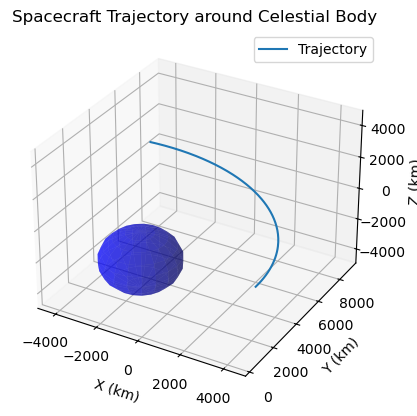

161
0


In [52]:
pos = np.array([5000, 400, 100])
r = np.linalg.norm(pos)
v = np.sqrt(body_struct["mu"] / r) + 0.2 # km/s, slightly
State0 = [pos[0], pos[1], pos[2], 0, v, 0] 



dt = 100
op, body_struct = gen_traj(Starting_state=State0, dt=dt)
plot_traj(op, body_struct)

print(len(op.states))
print(op.ts[0])


In [53]:
# for 10 points along traj gen images and test CR alg
images, edges, outs, states = get_images(op, body_struct, camera_spec_ellie, 10)


State at t=0.0s: [5.000e+03 4.000e+02 1.000e+02 0.000e+00 1.189e+00 0.000e+00]
State at t=1700.0s: [ 4.734e+03  2.364e+03  9.467e+01 -3.027e-01  1.104e+00 -6.054e-03]
State at t=3500.0s: [ 3.965e+03  4.205e+03  7.930e+01 -5.343e-01  9.324e-01 -1.069e-02]
State at t=5300.0s: [ 2.867e+03  5.707e+03  5.735e+01 -6.712e-01  7.368e-01 -1.342e-02]
State at t=7000.0s: [ 1.665e+03  6.809e+03  3.329e+01 -7.354e-01  5.623e-01 -1.471e-02]
State at t=8800.0s: [ 3.147e+02  7.671e+03  6.294e+00 -7.583e-01  4.002e-01 -1.517e-02]
State at t=10600.0s: [-1.048e+03  8.264e+03 -2.097e+01 -7.525e-01  2.625e-01 -1.505e-02]
State at t=12300.0s: [-2.311e+03  8.615e+03 -4.622e+01 -7.308e-01  1.526e-01 -1.462e-02]
State at t=14100.0s: [-3.598e+03  8.798e+03 -7.195e+01 -6.976e-01  5.406e-02 -1.395e-02]
State at t=15900.0s: [-4.818e+03  8.818e+03 -9.637e+01 -6.580e-01 -2.928e-02 -1.316e-02]


In [51]:
for out in outs:
    w, h = camera_spec_ellie["width"], camera_spec_ellie["height"]
    #state_to_edgepoints_module.plot_edge_points(out, w, h)

In [ ]:
# now running CR alg on the first image and edge points
estimates = []
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    edge = edges[i]
    state = states[i]

    # concatinate a 1 onto the edge points to make them homogeneous coordinates (i.e. [x, y, 1])
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], np.eye(3),print_stats=True, cr_alg=cr_alg)

Running CR alg on image 1/10
Calc Position:
 - (C->P in camera frame): [   0.     -1.16 5155.05] (5155.054765850123)m
 - (C->P in planet frame): [   0.     -1.16 5155.05] (5155.054765850123)m
Actual position:
 - (C->P in camera frame): [-5000.  -400.  -100.] (5016.971197844373)m
 - (C->P in planet frame): [-5000.  -400.  -100.] (5016.971197844373)m
Est - Actual:
 - (Camera frame): [5000.    398.84 5255.05] (7264.617729757429)m
 - (Planet frame): [5000.    398.84 5255.05] (7264.617729757429)m
Distance error: 138.08356800574984 m (2.7523292951%)
Angular error: 91.14 degrees
Running CR alg on image 2/10
Calc Position:
 - (C->P in camera frame): [   0.     -1.01 5361.63] (5361.628339296259)m
 - (C->P in planet frame): [   0.     -1.01 5361.63] (5361.628339296259)m
Actual position:
 - (C->P in camera frame): [-4733.5  -2364.27   -94.67] (5291.953505620418)m
 - (C->P in planet frame): [-4733.5  -2364.27   -94.67] (5291.953505620418)m
Est - Actual:
 - (Camera frame): [4733.5  2363.26 5456.3 ]